# 01 - Data Exploration

Initial inspection of the UCI Adult Income dataset before modelling. This notebook verifies the data pipeline,
examines feature distributions, cardinality spread, and class balance - all of which inform the diffusion schedule design.


In [1]:
import os, sys
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import load_split, load_meta, CAT_COLS, NUM_COLS

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load Preprocessed Data

In [2]:
meta = load_meta()
train = load_split('train')
val   = load_split('val')
test  = load_split('test')

print(f"Train:      {train['x_num'].shape[0]:,} samples")
print(f"Validation: {val['x_num'].shape[0]:,} samples")
print(f"Test:       {test['x_num'].shape[0]:,} samples")
print(f"Total:      {train['x_num'].shape[0] + val['x_num'].shape[0] + test['x_num'].shape[0]:,} samples")
print()
print(f"Numerical features:   {meta['n_num']} {NUM_COLS}")
print(f"Categorical features: {len(meta['cardinalities'])} {CAT_COLS}")
print(f"Cardinalities:        {meta['cardinalities']}")


Train:      36,177 samples
Validation: 4,522 samples
Test:       4,523 samples
Total:      45,222 samples

Numerical features:   6 ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: 8 ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Cardinalities:        [7, 16, 7, 14, 6, 5, 2, 41]


## 2. Class Balance

In [3]:
y_train = train['y']
class_counts = np.bincount(y_train)
class_pcts = class_counts / len(y_train) * 100

print("Target distribution (train):")
print(f"  Class 0 (<=50K): {class_counts[0]:,} ({class_pcts[0]:.1f}%)")
print(f"  Class 1 (>50K):  {class_counts[1]:,} ({class_pcts[1]:.1f}%)")
print(f"  Imbalance ratio: {class_counts[0]/class_counts[1]:.2f}:1")


Target distribution (train):
  Class 0 (<=50K): 27,211 (75.2%)
  Class 1 (>50K):  8,966 (24.8%)
  Imbalance ratio: 3.03:1


## 3. Numerical Feature Statistics

After QuantileTransformer preprocessing (fitted on train only), numerical features are approximately
standard-normal. Statistics below are post-transform.


In [4]:
num_df = pd.DataFrame(train['x_num'], columns=NUM_COLS)
print(f"Shape: {num_df.shape}")
print()
print(num_df.describe().round(3).to_string())


Shape: (36177, 6)

             age     fnlwgt  education-num  capital-gain  capital-loss  hours-per-week
count  36177.000  36177.000      36177.000     36177.000     36177.000       36177.000
mean      -0.018     -0.002          0.028        -4.596        -4.851           0.001
std        1.113      0.997          1.098         2.008         1.553           0.986
min       -5.199     -5.199         -5.199        -5.199        -5.199          -5.199
25%       -0.677     -0.687         -0.560        -5.199        -5.199          -0.113
50%       -0.015     -0.010          0.150        -5.199        -5.199          -0.113
75%        0.664      0.681          0.950        -5.199        -5.199           0.639
max        5.199      5.199          5.199         5.199         5.199           5.199


## 4. Categorical Cardinality Spread

The wide range (K=2 to K=41) motivates per-feature scheduling.
Features with higher $K$ carry more information capacity ($\log K$ nats) and respond differently to uniform noise.


Categorical features and their cardinalities:
  workclass          K = 7
  education          K = 16
  marital-status     K = 7
  occupation         K = 14
  relationship       K = 6
  race               K = 5
  sex                K = 2
  native-country     K = 41

Min K: 2 (sex)
Max K: 41 (native-country)
Ratio: 20x


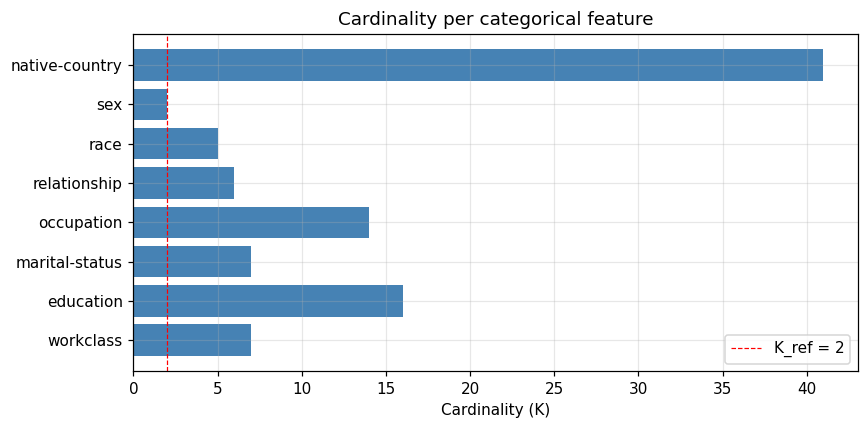

In [5]:
cardinalities = meta['cardinalities']

print("Categorical features and their cardinalities:")
for col, k in zip(CAT_COLS, cardinalities):
    print(f"  {col:<18s} K = {k}")

print(f"\nMin K: {min(cardinalities)} (sex)")
print(f"Max K: {max(cardinalities)} (native-country)")
print(f"Ratio: {max(cardinalities)//min(cardinalities)}x")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(CAT_COLS, cardinalities, color='steelblue')
ax.set_xlabel('Cardinality (K)')
ax.set_title('Cardinality per categorical feature')
ax.axvline(x=2, color='red', ls='--', lw=0.8, label='K_ref = 2')
ax.legend()
plt.tight_layout()
plt.show()


## 5. Information Capacity

Maximum mutual information each feature can carry is $\log K$ nats (achieved at zero noise, $\bar{\alpha}_t = 1$).


In [6]:
print("Maximum MI capacity per feature:")
for col, k in zip(CAT_COLS, cardinalities):
    print(f"  {col:<18s} K={k:<3d}  log(K) = {np.log(k):.3f} nats")

print(f"\nCapacity ratio (native-country / sex): {np.log(41)/np.log(2):.1f}x")


Maximum MI capacity per feature:
  workclass          K=7    log(K) = 1.946 nats
  education          K=16   log(K) = 2.773 nats
  marital-status     K=7    log(K) = 1.946 nats
  occupation         K=14   log(K) = 2.639 nats
  relationship       K=6    log(K) = 1.792 nats
  race               K=5    log(K) = 1.609 nats
  sex                K=2    log(K) = 0.693 nats
  native-country     K=41   log(K) = 3.714 nats

Capacity ratio (native-country / sex): 5.4x


## 6. Long-Tail Structure (native-country)

The highest-cardinality feature has a heavily skewed distribution - most categories are rare.
This makes it the hardest feature to generate accurately and the primary target for schedule improvement.


native-country (K=41) distribution:
  Most common:  33,020 samples (91.3%)
  Least common: 1 samples (0.00%)
  Categories with <100 samples: 32
  Categories with <50 samples:  19


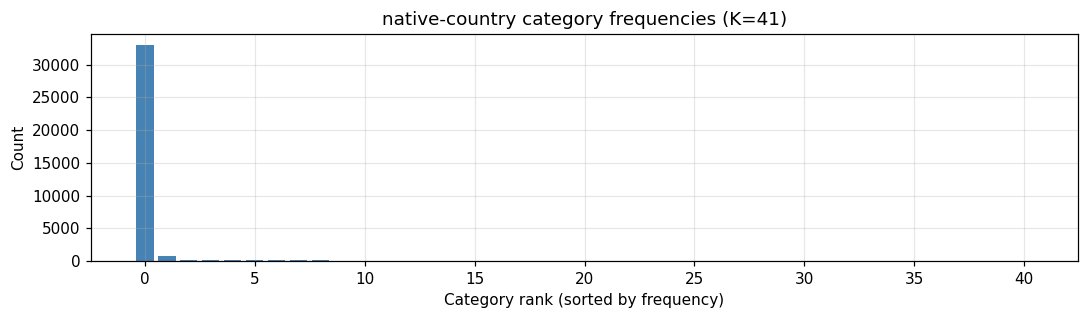

In [7]:
nc_col = CAT_COLS.index('native-country')
nc_counts = np.bincount(train['x_cat'][:, nc_col], minlength=41)

print(f"native-country (K=41) distribution:")
print(f"  Most common:  {nc_counts.max():,} samples ({nc_counts.max()/len(train['x_cat'])*100:.1f}%)")
print(f"  Least common: {nc_counts.min():,} samples ({nc_counts.min()/len(train['x_cat'])*100:.2f}%)")
print(f"  Categories with <100 samples: {(nc_counts < 100).sum()}")
print(f"  Categories with <50 samples:  {(nc_counts < 50).sum()}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(41), sorted(nc_counts, reverse=True), color='steelblue')
ax.set_xlabel('Category rank (sorted by frequency)')
ax.set_ylabel('Count')
ax.set_title('native-country category frequencies (K=41)')
plt.tight_layout()
plt.show()


## Summary

Key observations for diffusion schedule design:

- **Class imbalance** (3:1) motivates class-conditional generation with stratified label sampling.
- **Cardinality spread** (K=2 to K=41, a 20x ratio) creates a 5.4x difference in MI capacity between the simplest and most complex features.
- **Long-tail distributions** in high-K features (native-country has many categories with <100 samples) make these features hardest to reconstruct.
- The QuantileTransformer maps numericals to approximate standard-normal, suitable for the Gaussian diffusion branch.

These properties confirm Adult as an appropriate testbed for per-cardinality schedule adjustment.
